# Tytuł projektu:
Ryby w wodzie

# Członkowie zespołu:
Mateusz Adamczyk
Mikołaj Batkiewicz
Aleksander Kaczyński

# 1. Import bibliotek i wczytanie danych

In [ ]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import cv2
import random
import numpy as np

data_dir = Path("data") 
sets = ['train', 'valid', 'test']

fishes_data = {}

# Wczytanie danych
for s in sets:
    json_path = data_dir / s / "_annotations.coco.json"
    with open(json_path) as f:
        fishes_data[s] = json.load(f)

# Wyciągnięcie mapowania ID klasy na jej nazwę (korzystamy z folderu train jako bazy)
fish_categories = {ryba['id']: ryba['name'] for ryba in fishes_data['train']['categories']}

print(f"Pomyślnie wczytano dane z folderów: {sets}")

Pomyślnie wczytano dane z folderów: ['train', 'valid', 'test']


# Podstawowe statystyki i braki w danych - Liczba obrazów, Liczba unikalnych klas, Braki w anotacjach

In [8]:
basic_stats = []
total_images = 0
total_missing_annotations = 0

for s in sets:
    images = fishes_data[s]['images']
    annotations = fishes_data[s]['annotations']
    categories = fishes_data[s]['categories']
    
    # Zliczanie braków w anotacjach (zdjęcia bez żadnej ryby)
    img_ids_with_fish = set([ann['image_id'] for ann in annotations])
    all_img_ids = set([img['id'] for img in images])
    missing_anns = len(all_img_ids - img_ids_with_fish)
    
    total_images += len(images)
    total_missing_annotations += missing_anns
    
    basic_stats.append({
        'Zbiór': s.upper(),
        'Liczba obrazów': len(images),
        'Liczba unikalnych klas': len(categories),
        'Liczba wszystkich bboxów': len(annotations),
        'Obrazy bez anotacji (braki)': missing_anns
    })

df_basic_stats = pd.DataFrame(basic_stats)

print("--- PODSTAWOWE STATYSTYKI ZBIORU ---")
display(df_basic_stats) # Używamy display() w Jupyterze dla ładniejszej tabelki
print(f"\nŁączna liczba obrazów we wszystkich zbiorach: {total_images}")
print(f"Łączna liczba obrazów bez przypisanych bboxów: {total_missing_annotations}")

--- PODSTAWOWE STATYSTYKI ZBIORU ---


,Zbiór,Liczba obrazów,Liczba unikalnych klas,Liczba wszystkich bboxów,Obrazy bez anotacji (braki)
0,TRAIN,857,28,4246,0
1,VALID,267,28,1253,0
2,TEST,194,28,916,0



Łączna liczba obrazów we wszystkich zbiorach: 1318
Łączna liczba obrazów bez przypisanych bboxów: 0


# Analiza rozmiarów obrazów - Rozmiary obrazów (min, max, średni) (wykres punktowy)

--- STATYSTYKI ROZMIARÓW OBRAZÓW (Wszystkie zbiory) ---


,Szerokość,Wysokość
min,416.000000,416.000000
max,1024.000000,1024.000000
mean,606.421851,677.754173


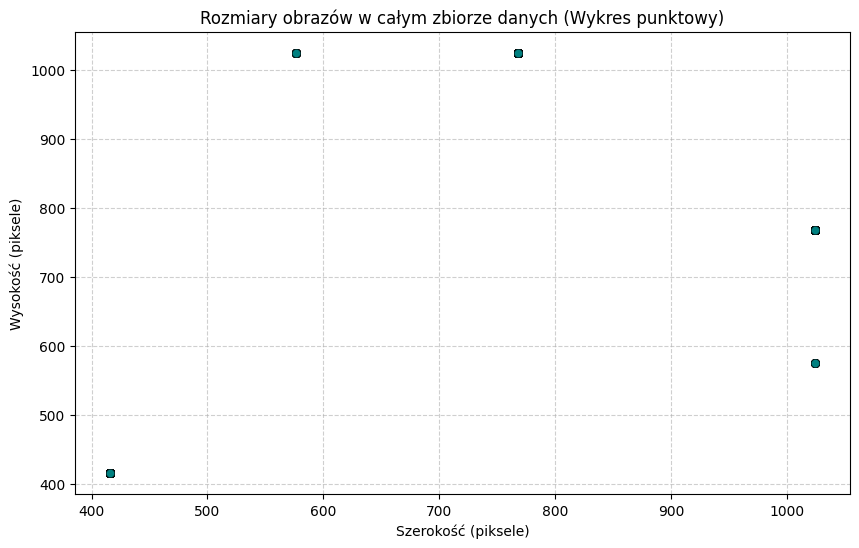

In [9]:
image_sizes = []

for s in sets:
    for img in fishes_data[s]['images']:
        image_sizes.append({
            'Szerokość': img['width'],
            'Wysokość': img['height']
        })

df_sizes = pd.DataFrame(image_sizes)

print("--- STATYSTYKI ROZMIARÓW OBRAZÓW (Wszystkie zbiory) ---")
display(df_sizes.describe().loc[['min', 'max', 'mean']])

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sizes, x='Szerokość', y='Wysokość', alpha=0.4, color='teal', edgecolor='black')
plt.title('Rozmiary obrazów w całym zbiorze danych (Wykres punktowy)')
plt.xlabel('Szerokość (piksele)')
plt.ylabel('Wysokość (piksele)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Detekcja - Balans klas i statystyki BBoxów - Balans klas, Liczba masek/boxów na klasę, Średnia powierzchnia bounding boxów, Średnia liczba bboxów na klasę

--- STATYSTYKI DETEKCJI ---
Średnia powierzchnia bounding boxa: 20202.27 pikseli kwadratowych
Średnia liczba bboxów przypadająca na jedną klasę: 237.59



/tmp/ipykernel_45222/1300467654.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=boxes_per_class.values, y=boxes_per_class.index, palette="viridis")


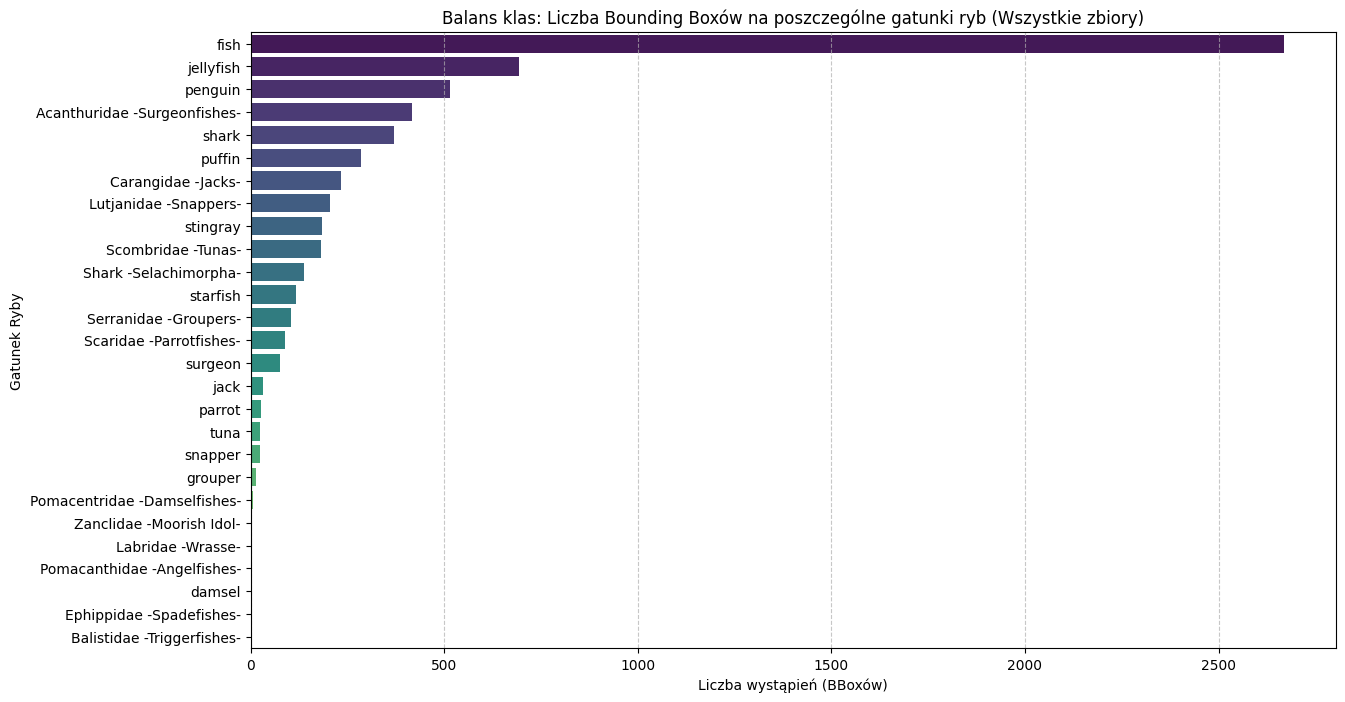

Tabela podsumowująca liczbę bboxów na klasę:


,Liczba BBoxów
Nazwa_Gatunku,
fish,2669
jellyfish,694
penguin,516
Acanthuridae -Surgeonfishes-,416
shark,371
puffin,284
Carangidae -Jacks-,234
Lutjanidae -Snappers-,206
stingray,184


In [10]:
all_annotations = []
for s in sets:
    all_annotations.extend(fishes_data[s]['annotations'])

df_bboxes = pd.DataFrame(all_annotations)
# Dodanie nazwy klasy na podstawie category_id
df_bboxes['Nazwa_Gatunku'] = df_bboxes['category_id'].map(fish_categories)

# 1. Obliczenia dla Detekcji
average_bbox_area = df_bboxes['area'].mean()
boxes_per_class = df_bboxes['Nazwa_Gatunku'].value_counts()
average_boxes_per_class = boxes_per_class.mean()

print("--- STATYSTYKI DETEKCJI ---")
print(f"Średnia powierzchnia bounding boxa: {average_bbox_area:.2f} pikseli kwadratowych")
print(f"Średnia liczba bboxów przypadająca na jedną klasę: {average_boxes_per_class:.2f}\n")

# 2. Wykres balansu klas (ile bboxów ma każda ryba)
plt.figure(figsize=(14, 8))
sns.barplot(x=boxes_per_class.values, y=boxes_per_class.index, palette="viridis")
plt.title('Balans klas: Liczba Bounding Boxów na poszczególne gatunki ryb (Wszystkie zbiory)')
plt.xlabel('Liczba wystąpień (BBoxów)')
plt.ylabel('Gatunek Ryby')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Tabela podsumowująca liczbę bboxów na klasę:")
display(pd.DataFrame(boxes_per_class).rename(columns={'count': 'Liczba BBoxów'}))

# Wizualizacja danych z etykietami - Wyświetl przykładowe obrazy wraz z bounding boxami

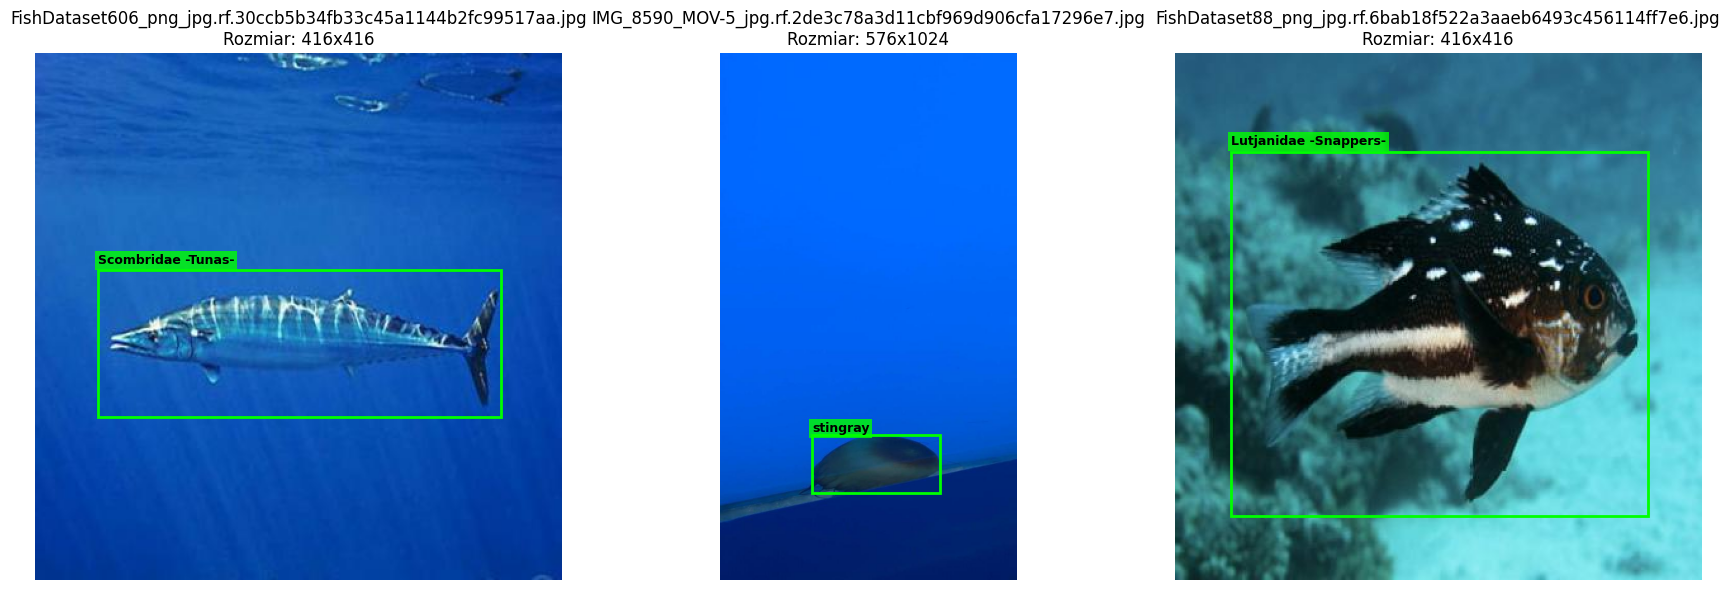

In [11]:
def imshow_fishes(set_name='train', num_images=3):
    data = fishes_data[set_name]
    images_list = data['images']
    anns_list = data['annotations']
    
    # Wybieramy losowe obrazy
    sample_imgs = random.sample(images_list, num_images)

    fig, axes = plt.subplots(1, num_images, figsize=(18, 6))
    if num_images == 1: axes = [axes]

    for ax, img_info in zip(axes, sample_imgs):
        img_path = data_dir / set_name / img_info['file_name']
        
        # Wczytanie i konwersja kolorów
        image = cv2.imread(str(img_path))
        if image is None:
            ax.set_title("Błąd wczytywania")
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        ax.imshow(image)
        ax.axis('off')
        
        # Wymiary rzeczywiste wrzucone w tytuł dla potwierdzenia
        ax.set_title(f"{img_info['file_name']}\nRozmiar: {img_info['width']}x{img_info['height']}")

        # Filtrowanie bboxów dla tego konkretnego zdjęcia
        fish_bboxes = [ann for ann in anns_list if ann['image_id'] == img_info['id']]

        # Rysowanie Bounding Boxów
        for ann in fish_bboxes:
            x, y, w, h = ann['bbox']
            # Rysujemy ramkę
            rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='#00FF00', facecolor='none')
            ax.add_patch(rect)
            
            # Podpis gatunku
            species_name = fish_categories[ann['category_id']]
            ax.text(x, max(0, y - 5), species_name, color='black', fontsize=9, weight='bold',
                    bbox=dict(facecolor='#00FF00', alpha=0.8, edgecolor='none', pad=2))

    plt.tight_layout()
    plt.show()

# Uruchomienie funkcji - wyświetlamy 3 losowe ryby ze zbioru testowego
imshow_fishes(set_name='test', num_images=3)